In [2]:
# Set plotting style
sns.set_theme(style="whitegrid")

# Load data
# We assume the notebook is located in 'QueueTorch/notebooks' and results in 'QueueTorch/results'
results_path = '../results/gradient_comparison.json'


with open(results_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

# 5.2

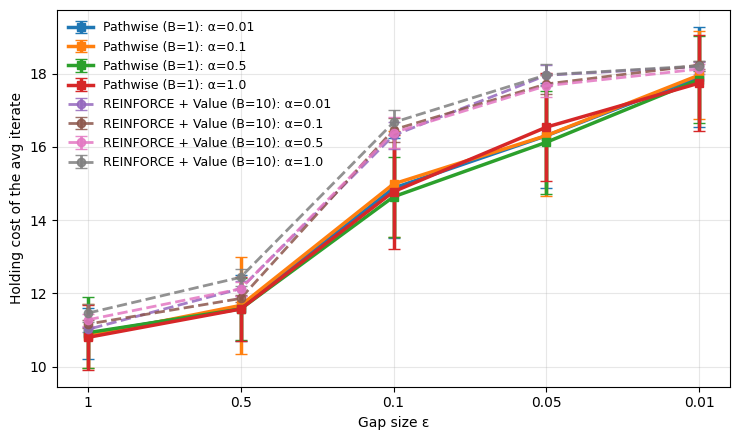

In [5]:
## Fig9.2
alphas = [0.01, 0.1, 0.5, 1.0]
gaps = [1, 0.5, 0.1, 0.05, 0.01]

# with open("/user/xz3355/queue-learning/cmu/pathwise_wc_cmu_multiclass.json", 'r') as f:
with open("/user/xz3355/QueueTorchReviews/cmu/pathwise_wc_cmu1_multiclass10.json", "r") as f:
    pw10 = json.load(f)
   
# with open("/user/xz3355/queue-learning/cmu/wc_reinforce_baseline_cmu_multiclass.json", "r") as f: 
with open("/user/xz3355/QueueTorchReviews/cmu/wc_reinforce_baseline_cmu_B10_multiclass10.json", "r") as f:
    rf10 = json.load(f)

pw10_results = []
rf10_results = []
pw10_count = 0
rf10_count = 0

for alpha in alphas:
    for gap in gaps:
        pw10_cost_list = []
        rf10_cost_list = []
        
        for x in pw10[str(alpha)][str(gap)]:
            pw10_count += 1
            pw10_cost_list.append(x['avg_cost'])
            
        for x in rf10[str(alpha)][str(gap)]:
            rf10_count += 1
            rf10_cost_list.append(x['avg_cost'])

        pw10_results.append({'alpha':alpha, 'gap': gap, 'avg_cost': np.mean(pw10_cost_list), 'cost_std': 1.96*np.std(pw10_cost_list)})
        rf10_results.append({'alpha':alpha, 'gap': gap, 'avg_cost': np.mean(rf10_cost_list), 'cost_std': 1.96*np.std(rf10_cost_list)/10})


fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = list(range(len(gaps))) 
gaps = sorted(gaps, reverse=False)

# ===== 1. Pathwise =====
pw_by_alpha = defaultdict(list)
for r in pw10_results:
    pw_by_alpha[r['alpha']].append(r)

for alpha, records in pw_by_alpha.items():
    records = sorted(records, key=lambda x: x['gap'], reverse=False)

    # gaps  = [r['gap'] for r in records]
    means = [r['avg_cost'] for r in records]
    stds  = [r['cost_std'] for r in records]

    ax.errorbar(
        x, means, yerr=stds,
        marker='s',
        linestyle='-',
        linewidth=2.5,
        capsize=4,
        label=f"Pathwise (B=1): α={alpha}"
    )

# ===== 2. REINFORCE =====
rf_by_alpha = defaultdict(list)
for r in rf10_results:
    rf_by_alpha[r['alpha']].append(r)

for alpha, records in rf_by_alpha.items():
    records = sorted(records, key=lambda x: x['gap'], reverse=False)

    # gaps  = [r['gap'] for r in records]
    means = [r['avg_cost'] for r in records]
    stds  = [r['cost_std'] for r in records]

    ax.errorbar(
        x, means, yerr=stds,
        marker='o',
        linestyle='--',
        linewidth=2,
        capsize=4,
        alpha=0.85,
        label=f"REINFORCE + Value (B=10): α={alpha}"
    )

# ===== 3. graph style =====
ax.set_xticks(x)
ax.set_xticklabels(gaps)
ax.set_xlabel("Gap size ε")
ax.set_ylabel("Holding cost of the avg iterate")
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
# plt.savefig("/user/xz3355/QueueTorchReviews/cmu/Fig9_2.png")

In [7]:
# Load data for admission control summary
summary_path = '../results/admission_control_like_buffer_summary.json'

with open(summary_path, 'r') as f:
    summary_data = json.load(f)

# Section 6